# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

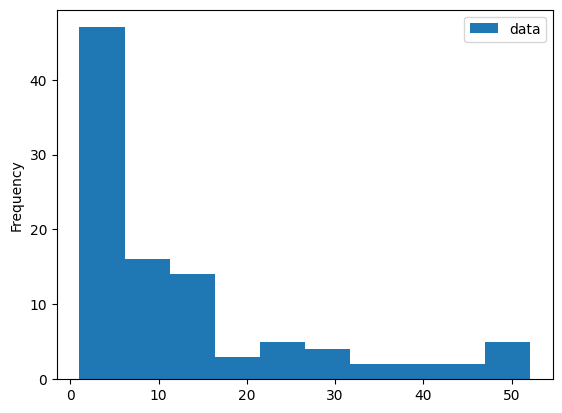

In [247]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

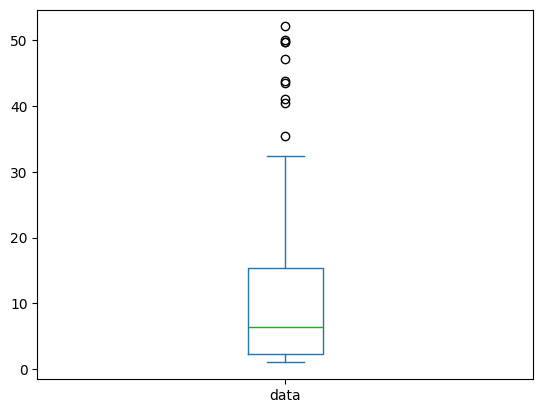

In [248]:
df.plot.box()

I would choose the histogram instead of the box plot because it gives a better visual of the distribution of the prices of the drugs. For example, we see that that majority of drugs fall around the 5 dollar range. The box plot shows us something similar but harder to idendify the actual range of the distribution. If looking at a high level the box plot would be a good option since it tells you the price range is around 0 to about 15 and with a heavy concentration around 5. Overall, I would say the histogram shows a holistic view of the price ranges of the drugs.
To make these graphs more visuals I would add x and y labels to get a better idea on what we are measuring. Additionally I would add value labels on the histogram to get exact values and make the bins more visible as it is currently hard to visualize the distribution. Also on the box plot I would add labels on the green line and at the top and bottom.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### Read in Cleaned Datasets

In [249]:
games_cleaned = pd.read_csv('games_cleaned.csv')
player_stats_cleaned = pd.read_csv('player_stats_cleaned.csv')
team_histories_cleaned = pd.read_csv('team_histories_cleaned.csv')
betting_stats_cleaned = pd.read_csv('betting_stats_cleaned.csv')  

/var/folders/fj/fkly19253s58fj8xwtwph5cw0000gn/T/ipykernel_52321/4158714534.py:1: DtypeWarning: Columns (12,14,15,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  games_cleaned = pd.read_csv('games_cleaned.csv')
/var/folders/fj/fkly19253s58fj8xwtwph5cw0000gn/T/ipykernel_52321/4158714534.py:2: DtypeWarning: Columns (10,11,12,15,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  player_stats_cleaned = pd.read_csv('player_stats_cleaned.csv')


In [251]:
team_histories_cleaned['seasonFounded_year'] = (
    team_histories_cleaned['seasonFounded']
    .astype(str)
    .str.extract(r'(\d{4})$')[0]
    .astype(int)
)
team_histories_cleaned['seasonActiveTill_year'] = (
    team_histories_cleaned['seasonActiveTill']
    .astype(str)
    .str.extract(r'(\d{4})$')[0]
    .astype(int)
)
team_histories_cleaned.loc[team_histories_cleaned['seasonActiveTill_year'] == 2100, 'seasonActiveTill_year'] = pd.Timestamp.now()
team_histories_cleaned = team_histories_cleaned.drop(columns=['seasonActiveTill', 'seasonFounded'])
team_histories_cleaned['seasonFounded_year'] = pd.to_datetime(team_histories_cleaned['seasonFounded_year'])
team_histories_cleaned['seasonActiveTill_year'] = pd.to_datetime(team_histories_cleaned['seasonActiveTill_year'])

/var/folders/fj/fkly19253s58fj8xwtwph5cw0000gn/T/ipykernel_52321/3252382094.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2026-06-16 22:37:36.116055' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  team_histories_cleaned.loc[team_histories_cleaned['seasonActiveTill_year'] == 2100, 'seasonActiveTill_year'] = pd.Timestamp.now()


### Player Stats Dataset

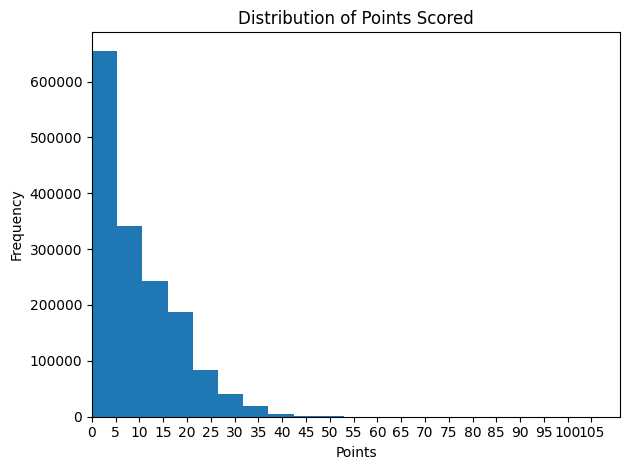

In [257]:
not_benched_players = player_stats_cleaned[player_stats_cleaned['numMinutes'] != 0 & player_stats_cleaned['numMinutes'].notna()]

max_points = int(not_benched_players['points'].max())

plt.hist(not_benched_players['points'], bins=20)
plt.title('Distribution of Points Scored')
plt.xlabel('Points')
plt.xlim(0, max_points + 5)
plt.xticks(np.arange(0, max_points + 1, 5))
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

With the histogram above we noticed that the most common amount of points scored in a game are towards the 0 - 5 range. Even though we eliminated the the players who were potentially benched in a game, there still seems to be many players with lower scores. Maybe we need to look into the numMinutes column in depth and remove players have been playing for a short amount of time to shift the histogram to the right a bit.

In [258]:
# Some cleaning on the numMinutes column to convert it to numeric and handle non-numeric values

def clean_minutes(x):

    # Missing values
    if pd.isna(x):
        return np.nan

    # MM:SS format
    if isinstance(x, str) and ':' in x:
        mins, secs = x.split(':')
        return int(mins) + int(secs) / 60

    # Everything else (floats and strings like "27")
    return float(x)

player_stats_cleaned['numMinutes'] = (
    player_stats_cleaned['numMinutes']
    .apply(clean_minutes)
)


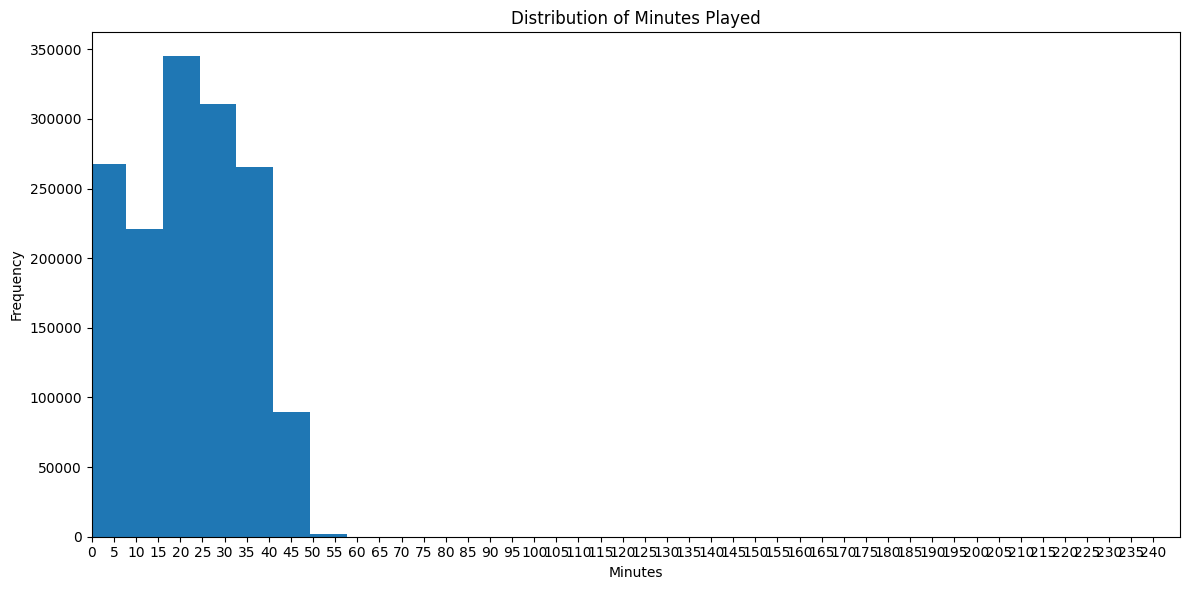

In [259]:
max_minutes = int(player_stats_cleaned['numMinutes'].max())

plt.figure(figsize=(12, 6))
plt.hist(player_stats_cleaned['numMinutes'], bins=30)
plt.title('Distribution of Minutes Played')
plt.xlabel('Minutes')
plt.xlim(0, max_minutes + 5)
plt.xticks(np.arange(0, max_minutes + 1, 5))
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This helps us see the distribution of the amount of time players played during a game. We see that the distribution is about binomial since it spikes at different times. For example, we see a spike at around 20 minutes and 30 minutes which seems to be the most common game time for players.

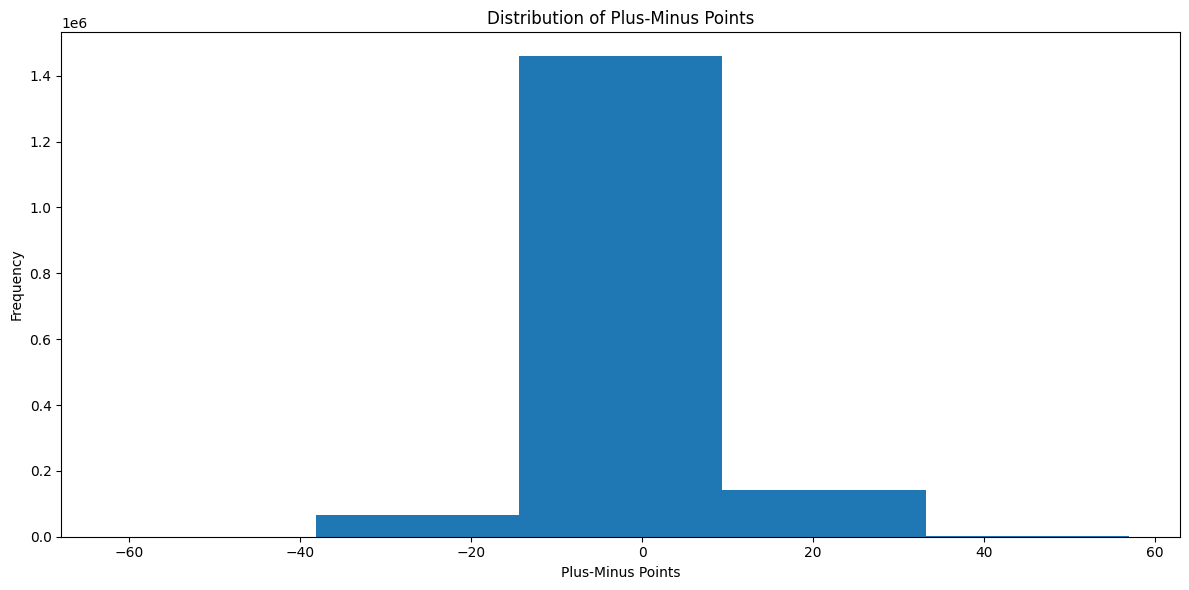

In [260]:
plt.figure(figsize=(12, 6))
plt.hist(player_stats_cleaned['plusMinusPoints'], bins=5)
plt.title('Distribution of Plus-Minus Points')
plt.xlabel('Plus-Minus Points')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This graph helps us find the distribution of plus-minus points for all players. Based on this normal distribution, we see that the most common plus-minus points is around -10 to 10 which makes sense. This is useful to know how impactful players are to a game.

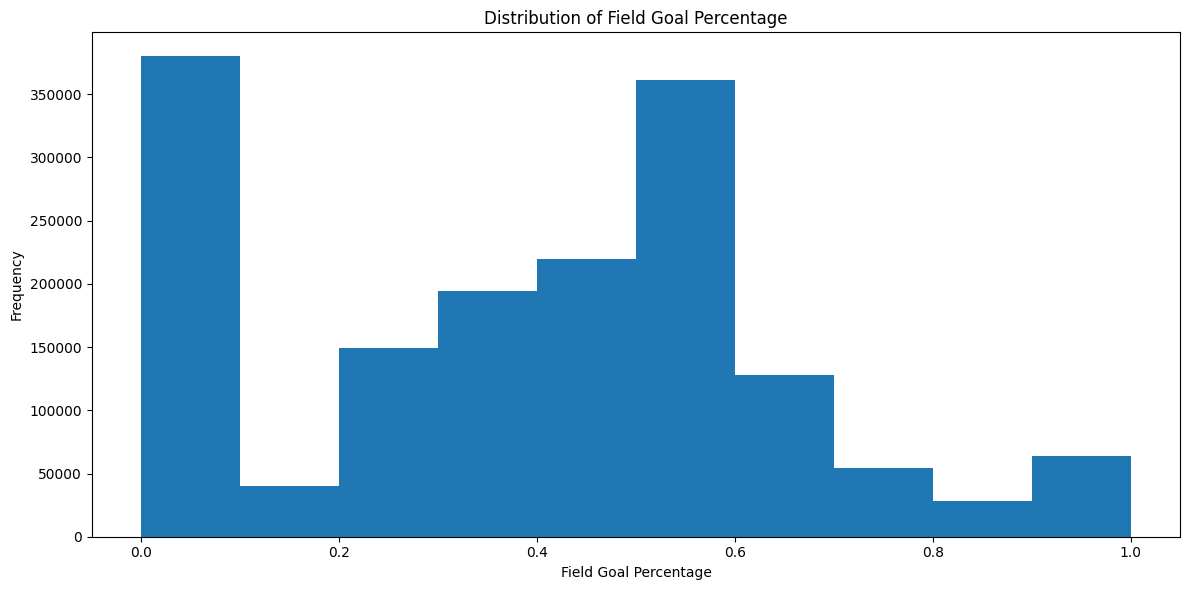

In [261]:
player_stats_cleaned = player_stats_cleaned[
    player_stats_cleaned['fieldGoalsMade'] <=
    player_stats_cleaned['fieldGoalsAttempted']
]
plt.figure(figsize=(12, 6))
plt.hist(player_stats_cleaned['fieldGoalsPercentage'], bins=10)
plt.title('Distribution of Field Goal Percentage')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



This graph shows us the percentage of successful shots as a distribution. Overall, we see binomial distribution here since it spikes at certain percentages. For example near 50% we see spike and around 10% we also see a spike.

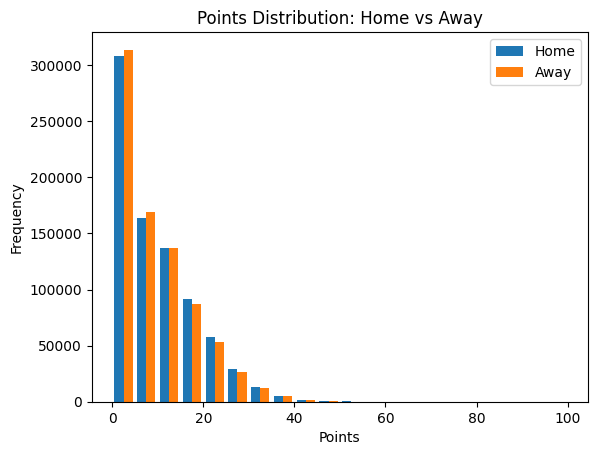

In [262]:
plt.hist(
    [player_stats_cleaned[player_stats_cleaned['home'] == True]['points'],
     player_stats_cleaned[player_stats_cleaned['home'] == False]['points']],
    bins=20,
    label=['Home', 'Away']
)

plt.xlabel('Points')
plt.ylabel('Frequency')
plt.title('Points Distribution: Home vs Away')
plt.legend()
plt.show()

This grouped histogram shows us the frequnecy of points that players have based on home vs away. We do notice that with more points we attribute that to the players playing at home rather than away which confirms my theory of being away helping with performance. In the beginning we do see that away has more wins however its in the lower points bin which is means not winning by alot. As the points spread increases we see a spread towards the home.

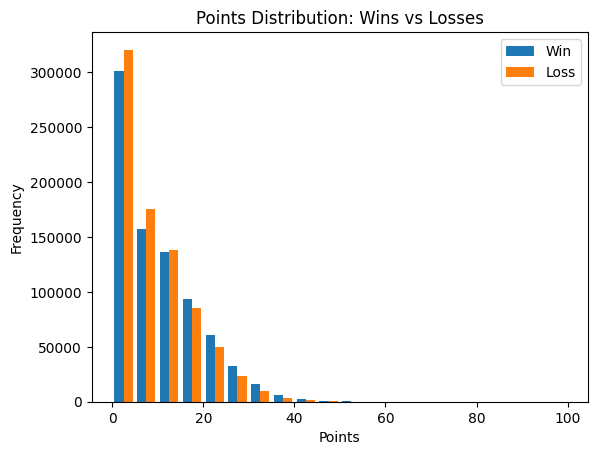

In [263]:
plt.hist(
    [player_stats_cleaned[player_stats_cleaned['win'] == True]['points'],
     player_stats_cleaned[player_stats_cleaned['win'] == False]['points']],
    bins=20,
    label=['Win', 'Loss']
)

plt.xlabel('Points')
plt.ylabel('Frequency')
plt.title('Points Distribution: Wins vs Losses')
plt.legend()
plt.show()

Similar to the histogram with home vs away, this shows the frequency of wins vs losses based on points bins. Similar to the theory above the higher the point spread the more this attributes to won games which makes sense. Players would tend to score more in games they win.

### Games Dataset

In [264]:
games_cleaned['winner'] = games_cleaned['winner'].astype(str)

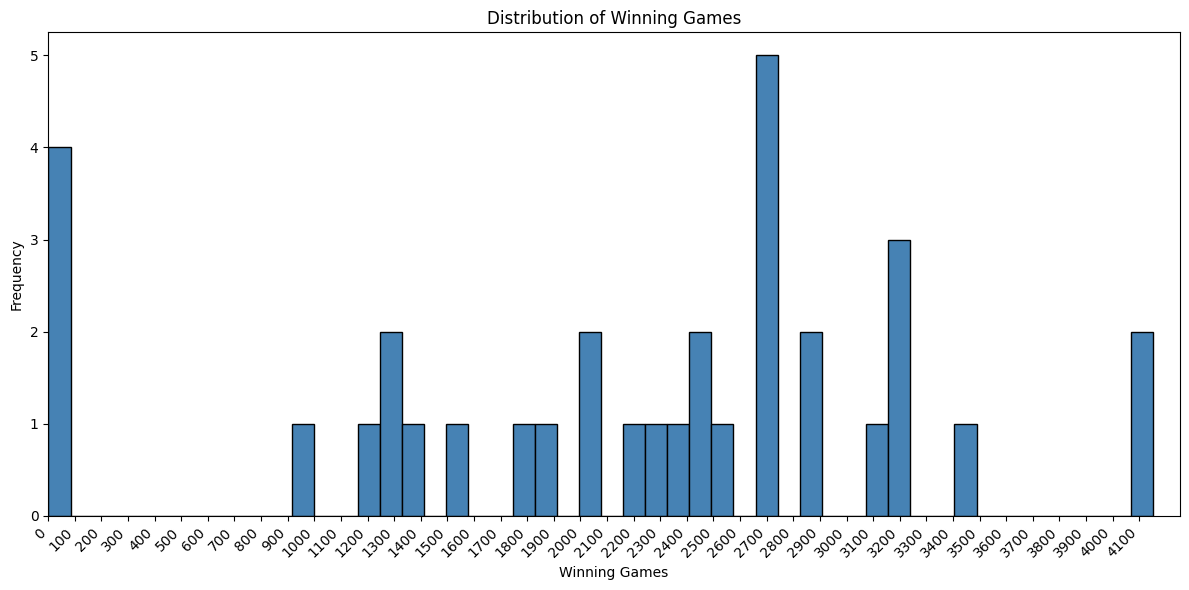

In [266]:
winner_counts = games_cleaned['winner'].value_counts().sort_index()
max_points = int(winner_counts.values.max())

plt.figure(figsize=(12, 6))
plt.hist(winner_counts.values, bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Winning Games')
plt.xlabel('Winning Games')
plt.xlim(0, max_points + 100)
plt.xticks(np.arange(0, max_points + 1, 100))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The histogram above shows us the distribution of games won by team. For example, we see that winning about 2600-2800 games is the most common followed by under 100 games. Overall, seems like there is no pattern here and it scattered throughout. This graph helps us visualize the amount of games won by teams and the frequency.

### Team Histories Dataset

In [267]:
team_histories_cleaned = team_histories_cleaned[team_histories_cleaned['league'] == 'NBA']
"""Filter for NBA teams only"""

'Filter for NBA teams only'

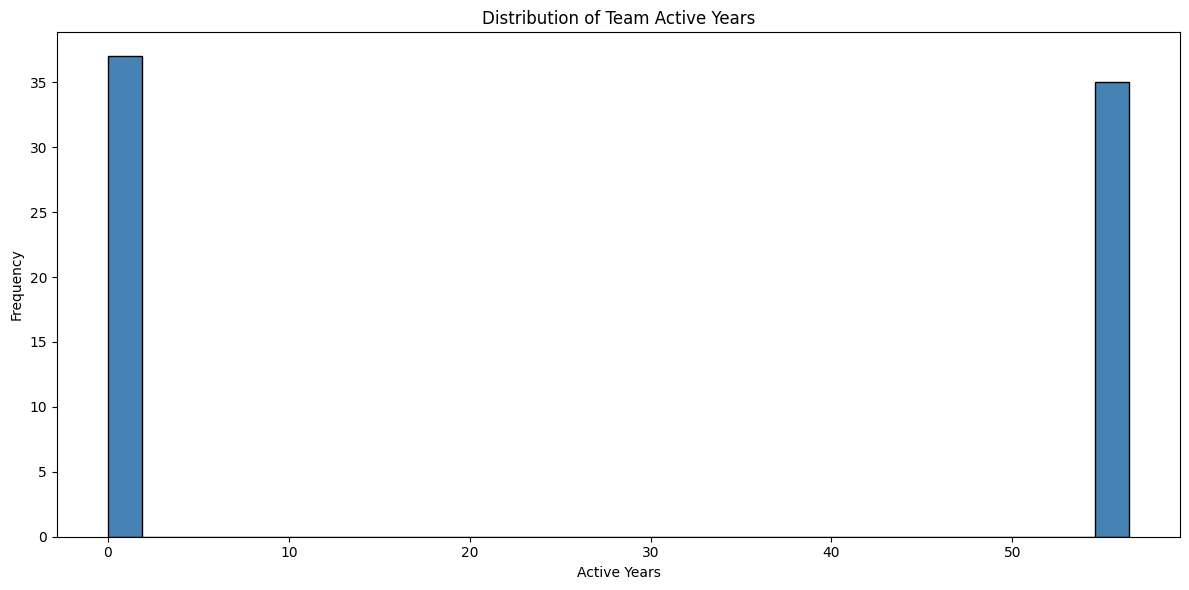

In [268]:
team_histories_cleaned['time_active_years'] = (team_histories_cleaned['seasonActiveTill_year'] - team_histories_cleaned['seasonFounded_year']).dt.days / 365.25

plt.figure(figsize=(12, 6))
plt.hist(team_histories_cleaned['time_active_years'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Team Active Years')
plt.xlabel('Active Years')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The histogram above shows us the distribution of active years for every team. For example, we see that majority of teams are only active for about 10 years. We do notice that the distribution is scattered with no real correlation. The only thing we do notice is that teams usually tend to be active for about 10 years or so until they get rebranded or name changed. This is important because active years of a team can impact performance.

### Betting Stats Dataset

In [269]:
betting_stats_cleaned['favoriteTeam'] = np.select(
    [
        betting_stats_cleaned['whos_favored'] == 'home',
        betting_stats_cleaned['whos_favored'] == 'away'
    ],
    [
        betting_stats_cleaned['home'],
        betting_stats_cleaned['away']
    ],
    default='N/A'
)

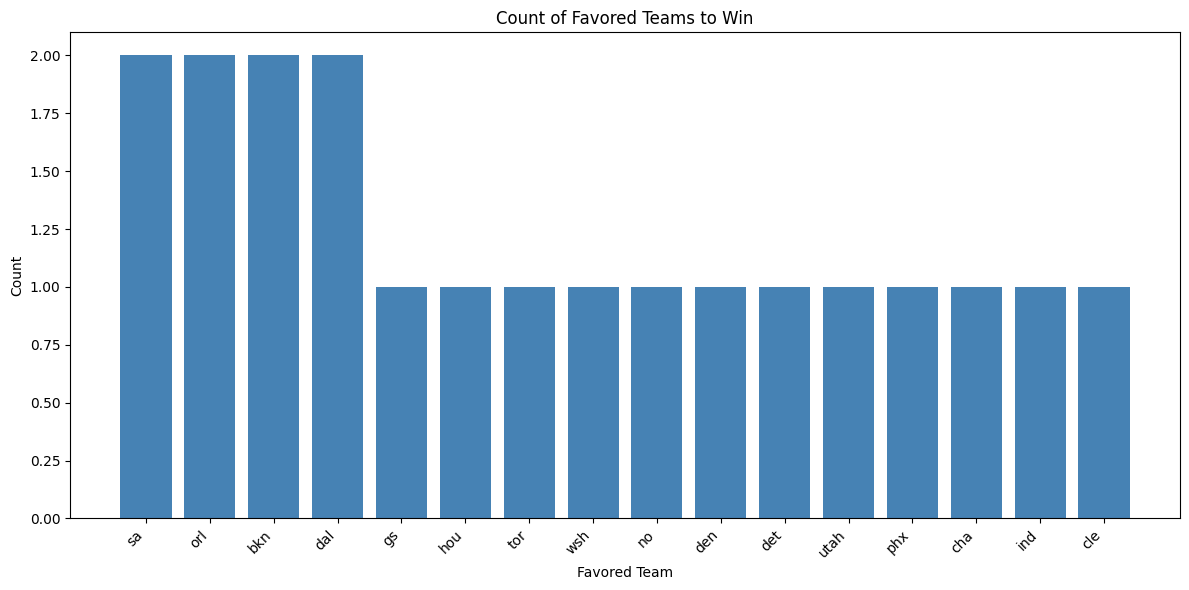

In [270]:
favorite_counts = betting_stats_cleaned['favoriteTeam'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(favorite_counts.index.astype(str), favorite_counts.values, color='steelblue')
plt.title('Count of Favored Teams to Win')
plt.xlabel('Favored Team')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Conclusions

- Overall, the data in all 4 datasets are usable. We also do see a connection between all datasets specifically on the team IDs and player IDs. The only concern would be on the betting stats data since the keys would be the home and away columns and the teams would be abbreviated. For this we would need to create a mapping dictionary to eventually join with the other daatsets. 

- The overall shape of distributions are a combination of skewed, uniform and binomial. For example, the player_stats dataset shows a right skewed distribution on the points scored. We also see a binomial distribution of the game time for each player as it spikes at different types and also for the field goal percentage. The games dataset shows more of a binomial distribution as it peaks at different moments and at some point almost uniform.  The team_histories dataset also shows somewhat of a right skewed distribution.

- There are a couple of outliers in these datasets. For example, the player_stats dataset shows some outliers at around 35-40 points. With further analysis we will probably find more outliers and the workflow around that would be to identify the cause behind these outliers and identify data quality issues to either engineer these rows or remove.

- If there are multiple related histograms, how does the distribution change across different groups? 

- What are the minimum and maximum values represented in each histogram?

- Bins control how the histogram groups the data. This can affect the way the distributions look in the histogram and can help us identify trends depending on the number of bins we use. Usually, the higher the bins the more granular the distribution gets and can be harder to identify the overall picture of the distribution and can show noise. This is why balancing with the correct amount of bins is key to be able to find the optimal distribution for business decisions. 

- Based on the features that I graphed, I did not have any normal distributions as mentioned above. We see a combination of right skewed, uniform and binomial. I think as we go through feature testing + engineering we will identify new distributions across the data.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

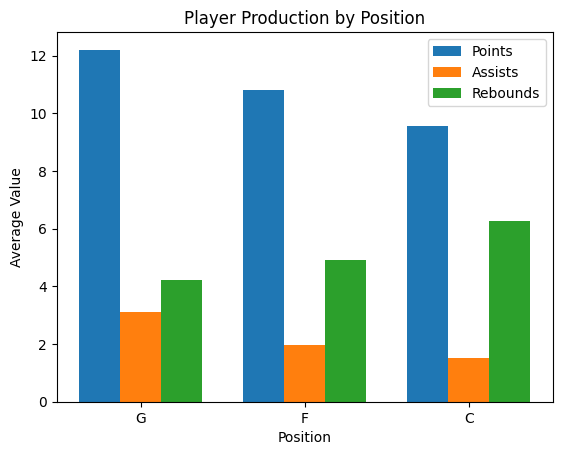

In [274]:
positions = ['G', 'F', 'C']

avg_points = (
    player_stats_cleaned.groupby('startingPosition')['points']
    .mean()
    .reindex(positions)
)

avg_assists = (
    player_stats_cleaned.groupby('startingPosition')['assists']
    .mean()
    .reindex(positions)
)

avg_rebounds = (
    player_stats_cleaned.groupby('startingPosition')['reboundsTotal']
    .mean()
    .reindex(positions)
)

x = np.arange(len(positions))
width = 0.25

plt.bar(x - width, avg_points, width, label='Points')
plt.bar(x, avg_assists, width, label='Assists')
plt.bar(x + width, avg_rebounds, width, label='Rebounds')

plt.xticks(x, positions)
plt.xlabel('Position')
plt.ylabel('Average Value')
plt.title('Player Production by Position')
plt.legend()

plt.show()